# BloodMNIST Attribution Reproducibility Benchmark

Parent model: `ResNet-18 (28)` using the local MedMNIST benchmark checkpoint.

This notebook is self-contained and uses BloodMNIST directly from `medmnist`.

In [1]:
# Uncomment if needed.
!pip install torch torchvision captum medmnist pandas scikit-learn matplotlib tqdm notebook ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 106.4 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import json
import random
from dataclasses import dataclass
from pathlib import Path

import medmnist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from captum.attr import DeepLift, GradientShap, IntegratedGradients, LayerGradCam
from medmnist import INFO, Evaluator
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm
from google.colab import drive
drive.mount('/content/drive')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Mounted at /content/drive


## Configuration
Set dataset, checkpoint, and experiment sizes.

In [ ]:
DATA_FLAG = 'bloodmnist'
RUN_NAME = 'resnet18_28_1'
WEIGHT_PATH = Path(r'/content/drive/MyDrive/model_weights/resnet18_28_2.pth')
CACHE_ROOT = Path('./cache_bloodmnist')
OUTPUT_ROOT = Path('./artifacts_bloodmnist')
DOWNLOAD_DATA = True
# hack to use the entire training, validation, and test sets
SUBSET_SIZE_TRAIN = 10**9
SUBSET_SIZE_VAL = 10**9
SUBSET_SIZE_TEST = 10**9
BATCH_SIZE = 64
STUDENT_BATCH_SIZE = 64
STUDENT_EPOCHS = 6
LEARNING_RATE = 1e-3
EXPLAINERS = ['deeplift', 'integrated_gradients', 'grad_cam', 'gradient_shap']
STUDENT_SIZES = {'tiny': (16, 2), 'small': (24, 3), 'medium': (32, 4)}
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
assert WEIGHT_PATH.exists(), f'Missing checkpoint: {WEIGHT_PATH}'

## Models and Cached Dataset
Define teacher/student models and the cached record format.
Caching is done to save compute

In [4]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes),
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class Bottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, self.expansion * planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion * planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes),
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        return F.relu(out)

class MedMNISTResNet(nn.Module):
    def __init__(self, block, num_blocks, in_channels, num_classes):
        super().__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(512 * block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        return self.linear(out)

def ResNet18(in_channels, num_classes):
    return MedMNISTResNet(BasicBlock, [2, 2, 2, 2], in_channels, num_classes)

class StudentNet(nn.Module):
    def __init__(self, in_channels, num_classes, width, depth):
        super().__init__()
        layers = []
        cur = in_channels
        hidden = width
        for _ in range(depth):
            layers += [nn.Conv2d(cur, hidden, 3, padding=1), nn.BatchNorm2d(hidden), nn.ReLU(), nn.MaxPool2d(2)]
            cur = hidden
            hidden *= 2
        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Linear(cur, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.head(x)

@dataclass
class CachedRecord:
    sample_id: int
    input_path: str
    teacher_label: int
    true_label: int
    teacher_probs: list[float]
    explanation_paths: dict
    split: str

class CachedStudentDataset(Dataset):
    def __init__(self, records, mode, explainer=None, shuffle_inputs=False):
        self.records = records
        self.mode = mode
        self.explainer = explainer
        self.input_indices = list(range(len(records)))
        if shuffle_inputs:
            rng = random.Random(SEED)
            rng.shuffle(self.input_indices)
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        rec = self.records[idx]
        x_rec = self.records[self.input_indices[idx]]
        x = torch.load(x_rec.input_path).float()
        y = torch.tensor(rec.teacher_label, dtype=torch.long)
        if self.mode == 'x_only':
            return x, y
        e = torch.load(rec.explanation_paths[self.explainer]).float()
        if e.ndim == x.ndim - 1:
            e = e.unsqueeze(0)
        if self.mode == 'e_only':
            return e, y
        if self.mode == 'x_random_plus_e':
            x = torch.rand_like(x)
        return torch.cat([x, e], dim=0), y

In [5]:
info = INFO[DATA_FLAG]
DataClass = getattr(medmnist, info['python_class'])
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]),
])
train_dataset_full = DataClass(split='train', transform=data_transform, download=DOWNLOAD_DATA, size=28)
val_dataset_full = DataClass(split='val', transform=data_transform, download=DOWNLOAD_DATA, size=28)
test_dataset_full = DataClass(split='test', transform=data_transform, download=DOWNLOAD_DATA, size=28)

train_subset = Subset(train_dataset_full, list(range(min(SUBSET_SIZE_TRAIN, len(train_dataset_full)))))
val_subset = Subset(val_dataset_full, list(range(min(SUBSET_SIZE_VAL, len(val_dataset_full)))))
test_subset = Subset(test_dataset_full, list(range(min(SUBSET_SIZE_TEST, len(test_dataset_full)))))

train_loader_full = DataLoader(train_dataset_full, batch_size=BATCH_SIZE, shuffle=False)
val_loader_full = DataLoader(val_dataset_full, batch_size=BATCH_SIZE, shuffle=False)
test_loader_full = DataLoader(test_dataset_full, batch_size=BATCH_SIZE, shuffle=False)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

parent = ResNet18(in_channels=n_channels, num_classes=n_classes).to(DEVICE)
state = torch.load(WEIGHT_PATH, map_location=DEVICE)
parent.load_state_dict(state['net'] if isinstance(state, dict) and 'net' in state else state, strict=True)
parent.eval()
parent

100%|██████████| 35.5M/35.5M [00:02<00:00, 12.5MB/s]


MedMNISTResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1,

## Parent Evaluation
Measure teacher performance on full splits.

In [6]:
@torch.no_grad()
def evaluate_parent(loader, split_name):
    y_true, y_score = [], []
    for x, y in loader:
        probs = torch.softmax(parent(x.to(DEVICE)), dim=1).cpu()
        y_true.append(y.squeeze().numpy())
        y_score.append(probs.numpy())
    y_true = np.concatenate(y_true)
    y_score = np.concatenate(y_score)
    evaluator = Evaluator(DATA_FLAG, split_name, size=28)
    auc, acc = evaluator.evaluate(y_score)
    macro_f1 = f1_score(y_true, y_score.argmax(axis=1), average='macro')
    return {'auc': auc, 'acc': acc, 'macro_f1': macro_f1}

parent_metrics = {
    'train': evaluate_parent(train_loader_full, 'train'),
    'val': evaluate_parent(val_loader_full, 'val'),
    'test': evaluate_parent(test_loader_full, 'test'),
}
pd.DataFrame(parent_metrics).T

,auc,acc,macro_f1
train,1.000000,1.000000,1.000000
val,0.998223,0.960864,0.957731
test,0.997808,0.960246,0.956942


In [7]:
def get_last_conv(module):
    for layer in reversed(list(module.modules())):
        if isinstance(layer, nn.Conv2d):
            return layer
    raise ValueError('No Conv2d layer found')

def build_explainers(model):
    return {
        'deeplift': DeepLift(model),
        'integrated_gradients': IntegratedGradients(model),
        'grad_cam': LayerGradCam(model, get_last_conv(model)),
        'gradient_shap': GradientShap(model),
    }

def normalize_map(attr, image_size=(28, 28)):
    if attr.ndim == 4:
        attr = attr.abs().mean(dim=1, keepdim=True)
    elif attr.ndim == 3:
        attr = attr.unsqueeze(1)
    attr = F.interpolate(attr, size=image_size, mode='bilinear', align_corners=False)
    flat = attr.flatten(1)
    min_v = flat.min(dim=1).values.view(-1, 1, 1, 1)
    max_v = flat.max(dim=1).values.view(-1, 1, 1, 1)
    return (attr - min_v) / (max_v - min_v + 1e-8)

def attribute_batch(explainer_name, explainer, x, targets):
    if explainer_name == 'grad_cam':
        attr = explainer.attribute(x, target=targets)
    elif explainer_name == 'gradient_shap':
        baselines = torch.cat([torch.zeros_like(x), x * 0.5], dim=0)
        attr = explainer.attribute(x, baselines=baselines, target=targets)
    elif explainer_name in {'deeplift', 'integrated_gradients'}:
        attr = explainer.attribute(x, baselines=torch.zeros_like(x), target=targets)
    else:
        raise ValueError(explainer_name)
    return normalize_map(attr)

explainers = build_explainers(parent)
smoke_x, _ = next(iter(val_loader))
smoke_logits = parent(smoke_x[:2].to(DEVICE))
smoke_targets = smoke_logits.argmax(dim=1)
smoke_shapes = {name: tuple(attribute_batch(name, explainer, smoke_x[:2].to(DEVICE), smoke_targets).shape) for name, explainer in explainers.items()}
smoke_shapes

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/deep_lift.py:296: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/usr/local/lib/python3.12/dist-packages/captum/log/dummy_log.py:54: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


{'deeplift': (2, 1, 28, 28),
 'integrated_gradients': (2, 1, 28, 28),
 'grad_cam': (2, 1, 28, 28),
 'gradient_shap': (2, 1, 28, 28)}

## Attribution Pipeline
Build explainers, normalize maps, and run a quick sanity check.

In [8]:
def cache_split(dataset_subset, split_name):
    split_dir = CACHE_ROOT / split_name
    (split_dir / 'inputs').mkdir(parents=True, exist_ok=True)
    for name in EXPLAINERS + ['random']:
        (split_dir / 'explanations' / name).mkdir(parents=True, exist_ok=True)
    records = []
    for idx in tqdm(range(len(dataset_subset)), desc=f'Caching {split_name}'):
        x, y_true = dataset_subset[idx]
        x = x.float()
        batch = x.unsqueeze(0).to(DEVICE)
        probs = torch.softmax(parent(batch), dim=1)
        teacher_label = int(probs.argmax(dim=1).item())
        input_path = split_dir / 'inputs' / f'{idx:05d}.pt'
        torch.save(x.cpu(), input_path)
        explanation_paths = {}
        targets = torch.tensor([teacher_label], device=DEVICE)
        for name in EXPLAINERS:
            attr = attribute_batch(name, explainers[name], batch, targets).squeeze(0).cpu()
            attr_path = split_dir / 'explanations' / name / f'{idx:05d}.pt'
            torch.save(attr, attr_path)
            explanation_paths[name] = str(attr_path)
        random_attr = torch.rand_like(attr)
        random_path = split_dir / 'explanations' / 'random' / f'{idx:05d}.pt'
        torch.save(random_attr, random_path)
        explanation_paths['random'] = str(random_path)
        records.append(CachedRecord(idx, str(input_path), teacher_label, int(y_true), probs.squeeze(0).detach().cpu().tolist(), explanation_paths, split_name))
    with open(CACHE_ROOT / f'{split_name}_records.json', 'w', encoding='utf-8') as f:
        json.dump([r.__dict__ for r in records], f, indent=2)
    return records

def load_cached_records(split_name):
    path = CACHE_ROOT / f'{split_name}_records.json'
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as f:
        payload = json.load(f)
    return [CachedRecord(**item) for item in payload]

train_records = load_cached_records('train') or cache_split(train_subset, 'train')
val_records = load_cached_records('val') or cache_split(val_subset, 'val')
test_records = load_cached_records('test') or cache_split(test_subset, 'test')
len(train_records), len(val_records), len(test_records)

Caching train:   0%|          | 0/11959 [00:00<?, ?it/s]

/tmp/ipykernel_1168/1594951344.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  records.append(CachedRecord(idx, str(input_path), teacher_label, int(y_true), probs.squeeze(0).detach().cpu().tolist(), explanation_paths, split_name))


Caching val:   0%|          | 0/1712 [00:00<?, ?it/s]

Caching test:   0%|          | 0/3421 [00:00<?, ?it/s]

(11959, 1712, 3421)

## Cache Explanations
Store inputs, explanations, and labels for student training.

In [9]:
def train_student(records, size_name, mode, explainer=None, shuffle_inputs=False):
    width, depth = STUDENT_SIZES[size_name]
    if mode == 'x_only':
        input_channels = n_channels
    elif mode == 'e_only':
        input_channels = 1
    else:
        input_channels = n_channels + 1
    model = StudentNet(input_channels, n_classes, width, depth).to(DEVICE)
    loader = DataLoader(CachedStudentDataset(records, mode, explainer, shuffle_inputs), batch_size=STUDENT_BATCH_SIZE, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    model.train()
    for _ in range(STUDENT_EPOCHS):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
    return model.eval()

@torch.no_grad()
def evaluate_student(model, records, mode, explainer=None, shuffle_inputs=False):
    loader = DataLoader(CachedStudentDataset(records, mode, explainer, shuffle_inputs), batch_size=STUDENT_BATCH_SIZE, shuffle=False)
    y_true, y_pred, y_prob, teacher_probs, true_labels = [], [], [], [], []
    for x, y in loader:
        probs = torch.softmax(model(x.to(DEVICE)), dim=1).cpu()
        y_true.extend(y.tolist())
        y_pred.extend(probs.argmax(dim=1).tolist())
        y_prob.append(probs.numpy())
    for rec in records:
        teacher_probs.append(rec.teacher_probs)
        true_labels.append(rec.true_label)
    y_prob = np.concatenate(y_prob)
    teacher_probs = np.asarray(teacher_probs)
    teacher_probs = np.clip(teacher_probs, 1e-8, 1.0)
    y_prob = np.clip(y_prob, 1e-8, 1.0)
    kl = np.mean(np.sum(teacher_probs * (np.log(teacher_probs) - np.log(y_prob)), axis=1))
    try:
        auc_teacher = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except ValueError:
        auc_teacher = float('nan')
    try:
        auc_true = roc_auc_score(true_labels, y_prob, multi_class='ovr', average='macro')
    except ValueError:
        auc_true = float('nan')
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro')),
        'kl_to_teacher': float(kl),
        'auc_teacher': float(auc_teacher),
        'auc_true': float(auc_true),
    }

results = []
for size_name in STUDENT_SIZES:
    base_model = train_student(train_records, size_name, 'x_only')
    base_metrics = evaluate_student(base_model, val_records, 'x_only')
    results.append({'student_size': size_name, 'explainer': 'none', 'mode': 'x_only', **base_metrics})
    for explainer in EXPLAINERS:
        xe_model = train_student(train_records, size_name, 'x_plus_e', explainer)
        xe_metrics = evaluate_student(xe_model, val_records, 'x_plus_e', explainer)
        xe_metrics['delta_accuracy'] = xe_metrics['accuracy'] - base_metrics['accuracy']
        results.append({'student_size': size_name, 'explainer': explainer, 'mode': 'x_plus_e', **xe_metrics})

        xr_model = train_student(train_records, size_name, 'x_plus_e', 'random')
        xr_metrics = evaluate_student(xr_model, val_records, 'x_plus_e', 'random')
        results.append({'student_size': size_name, 'explainer': explainer, 'mode': 'x_plus_e_random', **xr_metrics})

        xre_model = train_student(train_records, size_name, 'x_random_plus_e', explainer)
        xre_metrics = evaluate_student(xre_model, val_records, 'x_random_plus_e', explainer)
        results.append({'student_size': size_name, 'explainer': explainer, 'mode': 'x_random_plus_e', **xre_metrics})

        e_model = train_student(train_records, size_name, 'e_only', explainer)
        e_metrics = evaluate_student(e_model, val_records, 'e_only', explainer)
        results.append({'student_size': size_name, 'explainer': explainer, 'mode': 'e_only', **e_metrics})

        shuffled_metrics = evaluate_student(xe_model, val_records, 'x_plus_e', explainer, shuffle_inputs=True)
        results.append({'student_size': size_name, 'explainer': explainer, 'mode': 'x_plus_e_shuffled_input', **shuffled_metrics})

results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_ROOT / 'bloodmnist_results.csv', index=False)
results_df.head()

,student_size,explainer,mode,accuracy,macro_f1,kl_to_teacher,auc_teacher,auc_true,delta_accuracy
0,tiny,none,x_only,0.817757,0.779177,0.475237,0.981602,0.979513,NaN
1,tiny,deeplift,x_plus_e,0.897780,0.868144,0.323609,0.992810,0.985754,0.080023
2,tiny,deeplift,x_plus_e_random,0.698598,0.653694,0.696469,0.976336,0.974954,NaN
3,tiny,deeplift,x_random_plus_e,0.599883,0.512086,1.130055,0.955177,0.942301,NaN
4,tiny,deeplift,e_only,0.782710,0.738333,0.687813,0.972737,0.954509,NaN


## Student Training and Evaluation
Compare x-only, x+e, e-only, and random baselines.

In [10]:
summary_df = results_df.groupby(['student_size', 'explainer', 'mode'], as_index=False).mean(numeric_only=True)
summary_df

,student_size,explainer,mode,accuracy,macro_f1,kl_to_teacher,auc_teacher,auc_true,delta_accuracy
0,medium,deeplift,e_only,0.988318,0.989340,0.133190,0.999908,0.987510,NaN
1,medium,deeplift,x_plus_e,0.991822,0.991269,0.108459,0.999967,0.989904,0.049650
2,medium,deeplift,x_plus_e_random,0.903621,0.884754,0.273162,0.994670,0.993870,NaN
3,medium,deeplift,x_plus_e_shuffled_input,0.558995,0.546622,2.757440,0.882532,0.866411,NaN
4,medium,deeplift,x_random_plus_e,0.938668,0.936239,0.277515,0.999098,0.985876,NaN
...,...,...,...,...,...,...,...,...,...
58,tiny,integrated_gradients,x_plus_e,0.897780,0.890076,0.331367,0.999818,0.981424,0.080023
59,tiny,integrated_gradients,x_plus_e_random,0.796729,0.753281,0.535572,0.975917,0.975719,NaN
60,tiny,integrated_gradients,x_plus_e_shuffled_input,0.518107,0.479530,1.527009,0.962311,0.942171,NaN
61,tiny,integrated_gradients,x_random_plus_e,0.946262,0.945611,0.228544,0.999981,0.978377,NaN


In [11]:
ranking = summary_df[summary_df['mode'] == 'x_plus_e'].sort_values(['delta_accuracy', 'macro_f1'], ascending=False)
ranking

,student_size,explainer,mode,accuracy,macro_f1,kl_to_teacher,auc_teacher,auc_true,delta_accuracy
37,small,integrated_gradients,x_plus_e,1.000000,1.000000,0.076574,1.000000,0.989867,0.161799
32,small,gradient_shap,x_plus_e,0.996495,0.995816,0.077373,0.999998,0.989106,0.158294
22,small,deeplift,x_plus_e,0.982477,0.980464,0.082857,0.999692,0.991066,0.144276
27,small,grad_cam,x_plus_e,0.944509,0.934453,0.181724,0.999073,0.989018,0.106308
48,tiny,grad_cam,x_plus_e,0.912967,0.900041,0.320508,0.990818,0.983884,0.095210
58,tiny,integrated_gradients,x_plus_e,0.897780,0.890076,0.331367,0.999818,0.981424,0.080023
43,tiny,deeplift,x_plus_e,0.897780,0.868144,0.323609,0.992810,0.985754,0.080023
16,medium,integrated_gradients,x_plus_e,1.000000,1.000000,0.118346,1.000000,0.989350,0.057827
11,medium,gradient_shap,x_plus_e,0.998832,0.998894,0.124773,1.000000,0.987677,0.056659
1,medium,deeplift,x_plus_e,0.991822,0.991269,0.108459,0.999967,0.989904,0.049650


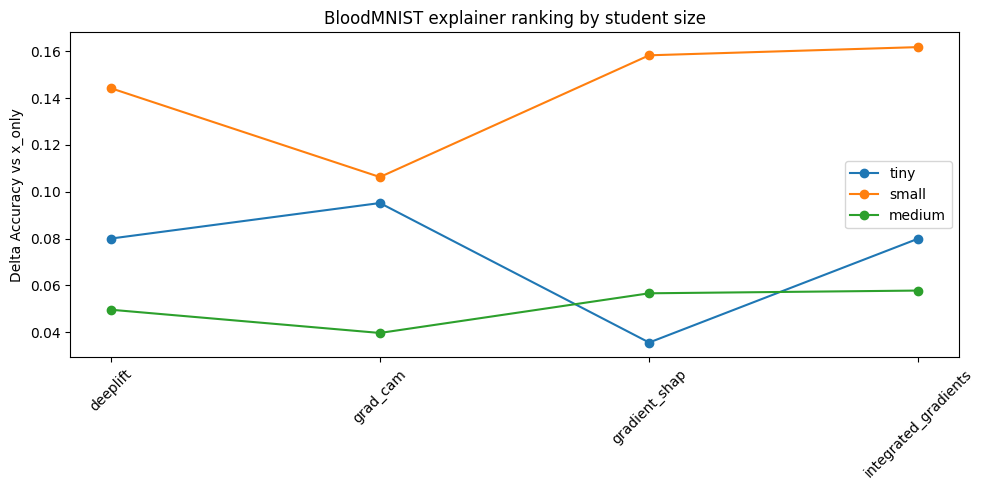

In [12]:
plot_df = summary_df[summary_df['mode'] == 'x_plus_e']
plt.figure(figsize=(10, 5))
for size_name in STUDENT_SIZES:
    subset = plot_df[plot_df['student_size'] == size_name]
    plt.plot(subset['explainer'], subset['delta_accuracy'], marker='o', label=size_name)
plt.xticks(rotation=45)
plt.ylabel('Delta Accuracy vs x_only')
plt.title('BloodMNIST explainer ranking by student size')
plt.legend()
plt.tight_layout()
plt.show()